# 03b - Offline RTX6000 Train OfficialMiniVLDiT

Run this notebook on Kaggle Nemotron RTX6000 without internet. It does not download Hugging Face models and does not decode video. It reads Notebook 02 prepared-data batch outputs plus Notebook 03a frozen-VLM encoded feature batch outputs, then trains the DiT/action head with pretrain and posttrain stages.

Required inputs:
- 4 Notebook 02 batch outputs: `gr00t_prepared_official_H16_batch01` ... `batch04`.
- 4 Notebook 03a batch outputs: `gr00t_vlm_encoded_H16_batch01_full_rtx6000_offline` ... `batch04_full_rtx6000_offline`.

Main outputs:
- `official_mini_vldit_H16_20subsets_offline_rtx6000/pretrain_checkpoint.pt`
- `official_mini_vldit_H16_20subsets_offline_rtx6000/posttrain_checkpoint.pt`
- `official_mini_vldit_H16_20subsets_offline_rtx6000/checkpoint_last.pt`
- `official_mini_vldit_H16_20subsets_offline_rtx6000/train_summary.json`

Stability note: this notebook keeps the full official-mini train scope and fixes NaN by sanitizing non-finite inputs, applying mask-safe flow loss, and failing fast on non-finite loss; it does not reduce samples, horizon, model size, or batch size to make the run pass.


In [1]:
from pathlib import Path
import json, random, time, os, math, hashlib
import numpy as np, pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.distributions import Beta

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("gpu:", GPU_NAME)
REQUIRE_RTX6000_GPU = os.getenv("REQUIRE_RTX6000_GPU", "1") == "1"
if REQUIRE_RTX6000_GPU and torch.cuda.is_available() and "6000" not in GPU_NAME:
    raise RuntimeError(f"This offline training notebook is intended for RTX6000/Nemotron, got: {GPU_NAME}")

SMOKE_TEST = False
ACTION_HORIZON = 16
STATE_HORIZON = 1
MAX_TRAIN_SAMPLES = 2048 if SMOKE_TEST else None
POSTTRAIN_MAX_SAMPLES = 512 if SMOKE_TEST else int(os.getenv("POSTTRAIN_MAX_SAMPLES", "50000"))
MAX_STEPS_PER_EPOCH = 20 if SMOKE_TEST else None
EPOCHS_PRETRAIN = 1
EPOCHS_POSTTRAIN = 1
RUN_PRETRAIN = True
RUN_POSTTRAIN = True
POSTTRAIN_SUBSETS = ["gr1_arms_only.CanSort"]
BATCH_SIZE = 256; NUM_WORKERS = 2
LR = float(os.getenv("LR", "1e-4")); POSTTRAIN_LR = float(os.getenv("POSTTRAIN_LR", "5e-5")); WEIGHT_DECAY = 1e-5; USE_AMP = True
HIDDEN_DIM = 512; NUM_LAYERS = 8; NUM_HEADS = 8; DROPOUT = 0.1
FAIL_ON_NONFINITE_LOSS = os.getenv("FAIL_ON_NONFINITE_LOSS", "1") == "1"
SANITIZE_NONFINITE_INPUTS = os.getenv("SANITIZE_NONFINITE_INPUTS", "1") == "1"
EXPECTED_PREPARED_BATCHES = int(os.getenv("EXPECTED_PREPARED_BATCHES", "4"))
EXPECTED_ENCODED_BATCHES = int(os.getenv("EXPECTED_ENCODED_BATCHES", "4"))
OUTPUT_ROOT = Path("/kaggle/working/gr00t_official_mini_runs"); OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_NAME = f"official_mini_vldit_H{ACTION_HORIZON}_20subsets_offline_rtx6000"


device: cuda
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
REQUIRED_PREPARED_FILES = [
    "states_train.npy", "actions_train_chunk.npy", "action_mask_train.npy",
    "video_frame_manifest_train.parquet", "video_frame_manifest_test.parquet",
    "normalization_stats.json", "prepare_report.json",
]

def _has_required(root):
    return root.is_dir() and all((root / name).exists() for name in REQUIRED_PREPARED_FILES)

def find_prepared_roots(action_horizon):
    exact = f"gr00t_prepared_official_H{action_horizon}"
    prefix = f"gr00t_prepared_official_H{action_horizon}_batch"
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists():
            continue
        for c in base.rglob(f"gr00t_prepared_official_H{action_horizon}*"):
            if c.name == exact or c.name.startswith(prefix):
                if _has_required(c):
                    candidates.append(c)
    dedup = {}
    for c in candidates:
        dedup[str(c.resolve())] = c
    roots = list(dedup.values())
    batch_roots = [r for r in roots if r.name.startswith(prefix)]
    if batch_roots:
        roots = batch_roots
    roots = sorted(roots, key=lambda x: str(x))
    if not roots:
        raise FileNotFoundError(f"Could not find prepared root H{action_horizon}. Mount Notebook 02 batch outputs or a merged prepared root.")
    return roots

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def combine_normalization_stats(stats_list):
    def combine(mean_key, std_key, n_key):
        total_n = int(sum(int(s.get(n_key, 0)) for s in stats_list))
        if total_n <= 0:
            raise ValueError(f"Invalid normalization count for {n_key}")
        sum_x = None; sum_x2 = None
        for s in stats_list:
            n = int(s.get(n_key, 0))
            if n <= 0:
                continue
            mean = np.asarray(s[mean_key], dtype=np.float64)
            std = np.asarray(s[std_key], dtype=np.float64)
            sx = mean * n
            sx2 = (std ** 2 + mean ** 2) * n
            sum_x = sx if sum_x is None else sum_x + sx
            sum_x2 = sx2 if sum_x2 is None else sum_x2 + sx2
        mean = sum_x / total_n
        var = np.maximum(sum_x2 / total_n - mean ** 2, 1e-12)
        std = np.sqrt(var)
        std = np.where(std < 1e-6, 1.0, std)
        return mean.astype(np.float32).tolist(), std.astype(np.float32).tolist(), total_n
    sm, ss, sn = combine("state_mean", "state_std", "state_n")
    am, ast, an = combine("action_mean", "action_std", "action_n")
    return {"state_mean": sm, "state_std": ss, "action_mean": am, "action_std": ast,
            "state_n": sn, "action_n": an, "space": "combined_raw_train_split"}

PREPARED_ROOTS = find_prepared_roots(ACTION_HORIZON)
PREPARED_ROOT_BY_ID = {i: r for i, r in enumerate(PREPARED_ROOTS)}
prepare_reports = [load_json(r / "prepare_report.json") for r in PREPARED_ROOTS]
stats_list = [load_json(r / "normalization_stats.json") for r in PREPARED_ROOTS]
stats = combine_normalization_stats(stats_list)
prepare_report = {
    "status": "combined",
    "state_horizon": STATE_HORIZON,
    "action_horizon": ACTION_HORIZON,
    "num_prepared_roots": len(PREPARED_ROOTS),
    "prepared_roots": [str(r) for r in PREPARED_ROOTS],
    "train_samples": int(sum(int(x.get("train_samples", 0)) for x in prepare_reports)),
    "test_samples": int(sum(int(x.get("test_samples", 0)) for x in prepare_reports)),
}
root_digest = hashlib.sha1("|".join(str(r) for r in PREPARED_ROOTS).encode("utf-8")).hexdigest()[:10]
print("PREPARED_ROOTS:")
for i, r in enumerate(PREPARED_ROOTS):
    rep = prepare_reports[i]
    print(f"  [{i}] {r} train={rep.get('train_samples')} test={rep.get('test_samples')}")
print(json.dumps({k: prepare_report[k] for k in ["num_prepared_roots", "train_samples", "test_samples"]}, indent=2))


PREPARED_ROOTS:
  [0] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch01-5-subsets/gr00t_prepared_official_H16_batch01 train=886742 test=222413
  [1] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch02-5-subsets/gr00t_prepared_official_H16_batch02 train=847478 test=212077
  [2] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch03-5-subsets/gr00t_prepared_official_H16_batch03 train=633706 test=157787
  [3] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch04-5-subsets/gr00t_prepared_official_H16_batch04 train=654143 test=163425
{
  "num_prepared_roots": 4,
  "train_samples": 3022069,
  "test_samples": 755702
}


In [3]:
REQUIRED_ENCODED_FILES = [
    "vl_features_train.npy", "vl_feature_index_train.parquet",
    "vl_features_test.npy", "vl_feature_index_test.parquet", "encode_summary.json",
]

def _has_encoded_required(root):
    return root.is_dir() and all((root / name).exists() for name in REQUIRED_ENCODED_FILES)

def find_encoded_roots(action_horizon):
    patterns = [
        f"gr00t_vlm_encoded_H{action_horizon}_batch*_full_rtx6000_offline",
        f"gr00t_vlm_encoded_H{action_horizon}_batch*_rtx6000_offline",
        f"gr00t_vlm_encoded_H{action_horizon}_20subsets*",
    ]
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists():
            continue
        for pattern in patterns:
            for c in base.rglob(pattern):
                if _has_encoded_required(c):
                    candidates.append(c)
    dedup = {}
    for c in candidates:
        dedup[str(c.resolve())] = c
    roots = sorted(dedup.values(), key=lambda x: str(x))
    if not roots:
        raise FileNotFoundError("Could not find VLM encoded outputs. Attach Notebook 03a batch outputs before running 03b.")
    return roots

def _summary_count(summary, split, key):
    return int((summary.get(split) or {}).get(key) or 0)

def _prepared_names_from_encode_summary(summary):
    names = []
    for raw in summary.get("prepared_roots") or []:
        name = Path(str(raw)).name
        if name:
            names.append(name)
    return names

PREPARED_ROOT_NAME_TO_ID = {root.name: rid for rid, root in PREPARED_ROOT_BY_ID.items()}
ENCODED_ROOTS = find_encoded_roots(ACTION_HORIZON)
if EXPECTED_ENCODED_BATCHES and len(ENCODED_ROOTS) < EXPECTED_ENCODED_BATCHES:
    raise RuntimeError(f"Expected at least {EXPECTED_ENCODED_BATCHES} encoded batch roots, found {len(ENCODED_ROOTS)}. Attach all Notebook 03a batch outputs.")
if EXPECTED_PREPARED_BATCHES and len(PREPARED_ROOTS) < EXPECTED_PREPARED_BATCHES:
    raise RuntimeError(f"Expected at least {EXPECTED_PREPARED_BATCHES} prepared batch roots, found {len(PREPARED_ROOTS)}. Attach all Notebook 02 batch outputs.")

encoded_root_infos = []
encoder_names = []
fallback_flags = []
primary_errors = []
for enc_id, root in enumerate(ENCODED_ROOTS):
    summary = json.loads((root / "encode_summary.json").read_text(encoding="utf-8"))
    prepared_names = _prepared_names_from_encode_summary(summary)
    unknown = [n for n in prepared_names if n not in PREPARED_ROOT_NAME_TO_ID]
    if unknown:
        raise RuntimeError(f"Encoded root {root} was built from prepared roots not attached to this notebook: {unknown}")
    if not prepared_names and len(PREPARED_ROOTS) == 1:
        prepared_names = [PREPARED_ROOTS[0].name]
    if not prepared_names:
        raise RuntimeError(f"Encoded root {root} does not report prepared_roots; cannot safely remap root_id.")
    encoder_names.append(summary.get("encoder_name"))
    fallback_flags.append(bool(summary.get("fallback_used")))
    primary_errors.append(summary.get("primary_error"))
    encoded_root_infos.append({
        "encoded_root_id": enc_id,
        "root": root,
        "summary": summary,
        "prepared_names": prepared_names,
        "prepared_global_ids": [PREPARED_ROOT_NAME_TO_ID[n] for n in prepared_names],
    })

aggregate_encode_summary = {
    "status": "combined",
    "num_encoded_roots": len(encoded_root_infos),
    "encoder_name": next((x for x in encoder_names if x), None),
    "encoder_names": sorted({str(x) for x in encoder_names if x}),
    "fallback_used": any(fallback_flags),
    "primary_errors": [e for e in primary_errors if e],
    "train": {
        "encoded": sum(_summary_count(info["summary"], "train", "encoded") for info in encoded_root_infos),
        "failed": sum(_summary_count(info["summary"], "train", "failed") for info in encoded_root_infos),
    },
    "test": {
        "encoded": sum(_summary_count(info["summary"], "test", "encoded") for info in encoded_root_infos),
        "failed": sum(_summary_count(info["summary"], "test", "failed") for info in encoded_root_infos),
    },
    "encoded_roots": [
        {"encoded_root_id": info["encoded_root_id"], "root": str(info["root"]), "prepared_names": info["prepared_names"],
         "train_encoded": _summary_count(info["summary"], "train", "encoded"),
         "test_encoded": _summary_count(info["summary"], "test", "encoded")}
        for info in encoded_root_infos
    ],
}

print("ENCODED_ROOTS:")
for info in encoded_root_infos:
    print(f"  [{info['encoded_root_id']}] {info['root']} prepared={info['prepared_names']} train={_summary_count(info['summary'], 'train', 'encoded')} test={_summary_count(info['summary'], 'test', 'encoded')}")
print(json.dumps({
    "num_encoded_roots": aggregate_encode_summary["num_encoded_roots"],
    "encoder_name": aggregate_encode_summary["encoder_name"],
    "fallback_used": aggregate_encode_summary["fallback_used"],
    "train_encoded": aggregate_encode_summary["train"]["encoded"],
    "test_encoded": aggregate_encode_summary["test"]["encoded"],
}, indent=2))


ENCODED_ROOTS:
  [0] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-encode-vlm-h16-batch01-rtx6000-offline/gr00t_vlm_encoded_H16_batch01_full_rtx6000_offline prepared=['gr00t_prepared_official_H16_batch01'] train=886742 test=222413
  [1] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-encode-vlm-h16-batch02-rtx6000-offline/gr00t_vlm_encoded_H16_batch02_full_rtx6000_offline prepared=['gr00t_prepared_official_H16_batch02'] train=847478 test=212077
  [2] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-encode-vlm-h16-batch04-rtx6000-offline/gr00t_vlm_encoded_H16_batch04_full_rtx6000_offline prepared=['gr00t_prepared_official_H16_batch04'] train=654143 test=163425
  [3] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-vlm-h16-batch03-rtx6000/gr00t_vlm_encoded_H16_batch03_full_rtx6000_offline prepared=['gr00t_prepared_official_H16_batch03'] train=633706 test=157787
{
  "num_encoded_roots": 4,
  "encoder_name": "/kaggle/input/notebooks/kimthanh211005/gr00t-eagle2-2b-offline-cache/eagle2_o

In [4]:
def _balanced_sample(df, max_samples, group_col="subset"):
    if max_samples is None or len(df) <= int(max_samples):
        return df.reset_index(drop=True)
    max_samples = int(max_samples)
    groups = [(k, g.copy()) for k, g in df.groupby(group_col, sort=True)]
    quota = max(1, max_samples // max(len(groups), 1))
    selected, leftovers = [], []
    for _, g in groups:
        if len(g) <= quota:
            selected.append(g)
        else:
            picked = g.sample(n=quota, random_state=SEED)
            selected.append(picked)
            leftovers.append(g.drop(picked.index))
    out = pd.concat(selected, ignore_index=False) if selected else df.iloc[:0]
    remaining = max_samples - len(out)
    if remaining > 0 and leftovers:
        rest = pd.concat(leftovers, ignore_index=False)
        if len(rest) > remaining:
            rest = rest.sample(n=remaining, random_state=SEED + 1)
        out = pd.concat([out, rest], ignore_index=False)
    return out.sort_values(["root_id", "subset", "episode_index", "frame_index", "sample_id"]).reset_index(drop=True)


In [5]:
class OfficialDataset(Dataset):
    def __init__(self, split, encoded_infos, max_samples=None, subset_filter=None):
        self.split = split
        self.roots = PREPARED_ROOT_BY_ID
        self.states = {rid: np.load(root / f"states_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.actions = {rid: np.load(root / f"actions_{split}_chunk.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.masks = {rid: np.load(root / f"action_mask_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.features = {}
        index_parts = []
        for info in encoded_infos:
            enc_id = int(info["encoded_root_id"])
            root = info["root"]
            feat_path = root / f"vl_features_{split}.npy"
            idx_path = root / f"vl_feature_index_{split}.parquet"
            self.features[enc_id] = np.load(feat_path, mmap_mode="r")
            idx = pd.read_parquet(idx_path).sort_values("feature_index").reset_index(drop=True)
            if "root_id" not in idx.columns:
                raise ValueError(f"Feature index is missing root_id: {idx_path}. Re-run Notebook 03a with the multi-root encoder version.")
            local_ids = sorted(int(x) for x in idx.root_id.dropna().unique().tolist())
            global_ids = [int(x) for x in info["prepared_global_ids"]]
            if len(global_ids) == 1:
                local_to_global = {local_id: global_ids[0] for local_id in local_ids}
            elif len(local_ids) == len(global_ids):
                local_to_global = {local_id: global_id for local_id, global_id in zip(local_ids, global_ids)}
            else:
                raise RuntimeError(f"Cannot remap local root ids {local_ids} from {root} to prepared roots {info['prepared_names']}")
            idx["encoded_root_id"] = enc_id
            idx["local_root_id"] = idx["root_id"].astype(int)
            idx["root_id"] = idx["local_root_id"].map(local_to_global).astype(int)
            index_parts.append(idx)
        if not index_parts:
            raise RuntimeError("No encoded index parts were loaded.")
        self.index = pd.concat(index_parts, ignore_index=True)
        sort_cols = [c for c in ["root_id", "subset", "episode_index", "frame_index", "sample_id", "encoded_root_id", "feature_index"] if c in self.index.columns]
        self.index = self.index.sort_values(sort_cols).reset_index(drop=True)
        self.requested_subset_filter = list(subset_filter or [])
        self.actual_subset_filter = []
        self.subset_fallback_used = False
        if self.requested_subset_filter:
            requested_df = self.index[self.index.subset.isin(self.requested_subset_filter)].copy()
            if requested_df.empty:
                counts = self.index.subset.value_counts()
                fallback_subset = str(counts.index[0])
                requested_df = self.index[self.index.subset == fallback_subset].copy()
                self.actual_subset_filter = [fallback_subset]
                self.subset_fallback_used = True
                print(f"WARN: requested posttrain subsets {self.requested_subset_filter} not found; fallback to {fallback_subset}")
            else:
                self.actual_subset_filter = sorted(requested_df.subset.astype(str).unique().tolist())
            self.index = requested_df.reset_index(drop=True)
        if max_samples is not None and len(self.index) > max_samples:
            self.index = _balanced_sample(self.index, max_samples, group_col="subset")
        self.index = self.index.reset_index(drop=True)
        self.encoded_root_ids = self.index["encoded_root_id"].to_numpy(np.int64)
        self.root_ids = self.index["root_id"].to_numpy(np.int64)
        self.sample_ids = self.index["sample_id"].to_numpy(np.int64)
        self.feature_indices = self.index["feature_index"].to_numpy(np.int64)
        self.subsets = self.index["subset"].astype(str).to_numpy()
        self.sm = np.asarray(stats["state_mean"], np.float32); self.ss = np.asarray(stats["state_std"], np.float32)
        self.am = np.asarray(stats["action_mean"], np.float32); self.asd = np.asarray(stats["action_std"], np.float32)
        feature_shapes = {enc_id: tuple(arr.shape[1:]) for enc_id, arr in self.features.items()}
        if len(set(feature_shapes.values())) != 1:
            raise RuntimeError(f"Encoded feature shapes are inconsistent across batches: {feature_shapes}")
        self.feature_shape = next(iter(feature_shapes.values()))
    def __len__(self): return len(self.sample_ids)
    def __getitem__(self, i):
        enc_id = int(self.encoded_root_ids[i]); rid = int(self.root_ids[i]); sid = int(self.sample_ids[i]); fid = int(self.feature_indices[i])
        raw_state = np.asarray(self.states[rid][sid], np.float32)
        raw_action = np.asarray(self.actions[rid][sid], np.float32)
        mask = np.asarray(self.masks[rid][sid], np.float32).copy()
        vl = np.asarray(self.features[enc_id][fid], np.float32)
        if SANITIZE_NONFINITE_INPUTS:
            state_finite = np.isfinite(raw_state)
            action_finite = np.isfinite(raw_action)
            vl_finite = np.isfinite(vl)
            raw_state = np.where(state_finite, raw_state, 0.0).astype(np.float32, copy=False)
            raw_action = np.where(action_finite, raw_action, 0.0).astype(np.float32, copy=False)
            mask = np.where(np.isfinite(mask), mask, 0.0).astype(np.float32, copy=False)
            mask = mask * action_finite.astype(np.float32)
            vl = np.where(vl_finite, vl, 0.0).astype(np.float32, copy=False)
        mask = np.clip(mask, 0.0, 1.0).astype(np.float32, copy=False)
        state = ((raw_state - self.sm) / self.ss).astype(np.float32, copy=False)
        action = ((raw_action - self.am) / self.asd).astype(np.float32, copy=False)
        if SANITIZE_NONFINITE_INPUTS:
            state = np.nan_to_num(state, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
            action = np.nan_to_num(action, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
            vl = np.nan_to_num(vl, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        action = action * mask
        return {"state": torch.from_numpy(state), "action": torch.from_numpy(action),
                "mask": torch.from_numpy(mask), "vl": torch.from_numpy(vl),
                "sample_id": sid, "root_id": rid, "encoded_root_id": enc_id, "subset": str(self.subsets[i])}

def collate(batch):
    out = {k: torch.stack([b[k] for b in batch]) for k in ["state", "action", "mask", "vl"]}
    out["sample_id"] = torch.tensor([b["sample_id"] for b in batch])
    out["root_id"] = torch.tensor([b["root_id"] for b in batch])
    out["encoded_root_id"] = torch.tensor([b["encoded_root_id"] for b in batch])
    out["subset"] = [b["subset"] for b in batch]
    return out

def make_loader(ds, shuffle, batch_size=BATCH_SIZE):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS,
                      pin_memory=torch.cuda.is_available(), drop_last=False, collate_fn=collate)

pretrain_ds = OfficialDataset("train", encoded_root_infos, MAX_TRAIN_SAMPLES)
test_ds = OfficialDataset("test", encoded_root_infos, None)
posttrain_ds = OfficialDataset("train", encoded_root_infos, POSTTRAIN_MAX_SAMPLES, subset_filter=POSTTRAIN_SUBSETS)
FEATURE_DIM = int(pretrain_ds.feature_shape[-1]); NUM_TOKENS = int(pretrain_ds.feature_shape[0])
print("pretrain_samples:", len(pretrain_ds), "posttrain_samples:", len(posttrain_ds), "FEATURE_DIM:", FEATURE_DIM, "tokens:", NUM_TOKENS)
print("test_samples:", len(test_ds))
print("posttrain_subsets:", posttrain_ds.actual_subset_filter, "fallback:", posttrain_ds.subset_fallback_used)
print("feature_shapes:", {enc_id: tuple(arr.shape) for enc_id, arr in pretrain_ds.features.items()})

def inspect_dataset_batch(ds, name, n=512):
    n = min(int(n), len(ds))
    if n <= 0:
        return {"name": name, "samples_checked": 0}
    idxs = np.linspace(0, len(ds) - 1, n, dtype=np.int64)
    report = {"name": name, "samples_checked": int(n), "nonfinite_state": 0, "nonfinite_action": 0, "nonfinite_vl": 0, "mask_sum_zero": 0}
    for idx in idxs:
        item = ds[int(idx)]
        report["nonfinite_state"] += int(not torch.isfinite(item["state"]).all())
        report["nonfinite_action"] += int(not torch.isfinite(item["action"]).all())
        report["nonfinite_vl"] += int(not torch.isfinite(item["vl"]).all())
        report["mask_sum_zero"] += int(float(item["mask"].sum()) <= 0.0)
    print("dataset_finite_check", json.dumps(report, indent=2))
    if report["nonfinite_state"] or report["nonfinite_action"] or report["nonfinite_vl"]:
        raise RuntimeError(f"Non-finite tensors remain after sanitization in {name}: {report}")
    return report

input_quality_reports = [inspect_dataset_batch(pretrain_ds, "pretrain"), inspect_dataset_batch(posttrain_ds, "posttrain")]


pretrain_samples: 3022069 posttrain_samples: 50000 FEATURE_DIM: 1536 tokens: 2
test_samples: 755702
posttrain_subsets: ['gr1_arms_only.CanSort'] fallback: False
feature_shapes: {0: (886742, 2, 1536), 1: (847478, 2, 1536), 2: (654143, 2, 1536), 3: (633706, 2, 1536)}
dataset_finite_check {
  "name": "pretrain",
  "samples_checked": 512,
  "nonfinite_state": 0,
  "nonfinite_action": 0,
  "nonfinite_vl": 0,
  "mask_sum_zero": 0
}
dataset_finite_check {
  "name": "posttrain",
  "samples_checked": 512,
  "nonfinite_state": 0,
  "nonfinite_action": 0,
  "nonfinite_vl": 0,
  "mask_sum_zero": 0
}


In [6]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim, buckets=1000):
        super().__init__()
        self.buckets = buckets
        self.embed = nn.Embedding(buckets, hidden_dim)
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
    def forward(self, t):
        idx = torch.clamp((t * self.buckets).long(), 0, self.buckets - 1)
        return self.mlp(self.embed(idx))

class CrossBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout):
        super().__init__()
        self.n1 = nn.LayerNorm(hidden_dim)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(hidden_dim)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(hidden_dim)
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim), nn.Dropout(dropout)
        )
    def forward(self, x, mem):
        y = self.n1(x)
        x = x + self.sa(y, y, y, need_weights=False)[0]
        y = self.n2(x)
        x = x + self.ca(y, mem, mem, need_weights=False)[0]
        return x + self.ff(self.n3(x))

class OfficialMiniVLDiT(nn.Module):
    def __init__(self, state_dim, action_dim, state_horizon, action_horizon, vl_dim,
                 hidden_dim=512, layers=8, heads=8, dropout=0.1, buckets=1000):
        super().__init__()
        self.state_horizon = state_horizon
        self.action_horizon = action_horizon
        self.state_proj = nn.Linear(state_dim, hidden_dim)
        self.action_proj = nn.Linear(action_dim, hidden_dim)
        self.vl_proj = nn.Linear(vl_dim, hidden_dim)
        self.time = TimeEmbedding(hidden_dim, buckets)
        self.state_pos = nn.Embedding(state_horizon, hidden_dim)
        self.action_pos = nn.Embedding(action_horizon, hidden_dim)
        self.blocks = nn.ModuleList([CrossBlock(hidden_dim, heads, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, action_dim)
    def forward(self, noisy_action, state_history, vl_features, t):
        s_pos = self.state_pos(torch.arange(self.state_horizon, device=noisy_action.device))[None]
        a_pos = self.action_pos(torch.arange(self.action_horizon, device=noisy_action.device))[None]
        s = self.state_proj(state_history) + s_pos
        a = self.action_proj(noisy_action) + a_pos
        x = torch.cat([s, a], dim=1) + self.time(t)[:, None, :]
        mem = self.vl_proj(vl_features)
        for block in self.blocks:
            x = block(x, mem)
        return self.out(self.norm(x[:, self.state_horizon:]))

model = OfficialMiniVLDiT(44, 44, STATE_HORIZON, ACTION_HORIZON, FEATURE_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)
num_params = sum(p.numel() for p in model.parameters())
print("params:", num_params)

params: 35272236


params: 35272236


/tmp/ipykernel_65/1844695107.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())


pretrain epoch 1/1:   0%|          | 0/11805 [00:00<?, ?it/s]

/tmp/ipykernel_65/1844695107.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):


posttrain epoch 1/1:   0%|          | 0/196 [00:00<?, ?it/s]

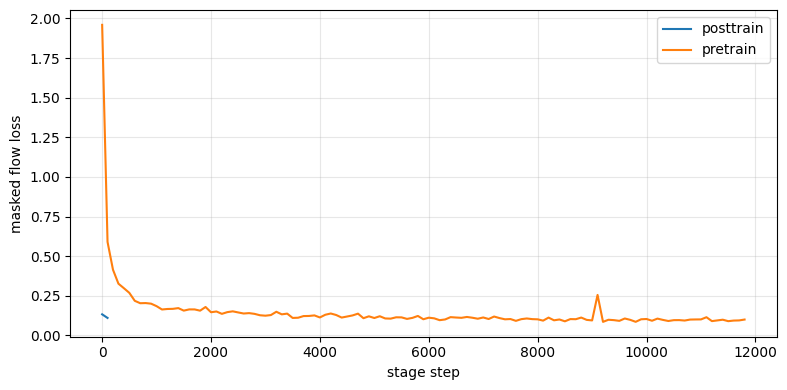

{
  "status": "completed",
  "run_dir": "/kaggle/working/gr00t_official_mini_runs/official_mini_vldit_H16_20subsets_offline_rtx6000",
  "best_stage": "posttrain",
  "best_checkpoint": "posttrain_checkpoint.pt",
  "full_epoch_completed": true,
  "pretrain_completed": true,
  "posttrain_completed": true,
  "pretrain_samples": 3022069,
  "posttrain_samples": 50000,
  "test_samples": 755702,
  "num_prepared_roots": 4,
  "prepared_roots": [
    "/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch01-5-subsets/gr00t_prepared_official_H16_batch01",
    "/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch02-5-subsets/gr00t_prepared_official_H16_batch02",
    "/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch03-5-subsets/gr00t_prepared_official_H16_batch03",
    "/kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch04-5-subsets/gr00t_prepared_official_H16_batch04"
  ],
  "num_encoded_roots": 4,
  "encoded_roots": [
    "/kaggle/input/notebooks/kimthanh

In [7]:
run_dir = OUTPUT_ROOT / RUN_NAME; run_dir.mkdir(parents=True, exist_ok=True)
train_encoded_total = int(aggregate_encode_summary["train"]["encoded"])
test_encoded_total = int(aggregate_encode_summary["test"]["encoded"])
base_cfg = {"model_name": "OfficialMiniVLDiT", "state_horizon": STATE_HORIZON, "action_horizon": ACTION_HORIZON,
       "state_dim": 44, "action_dim": 44, "vl_feature_dim": FEATURE_DIM, "vl_num_tokens": NUM_TOKENS,
       "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS, "num_heads": NUM_HEADS,
       "dropout": DROPOUT, "num_timestep_buckets": 1000, "timestep_sampling": "Beta(1.5,1.0)",
       "target_velocity_sign": "action_minus_noise", "masked_loss": True, "nan_safe_training": True, "learning_rate": LR,
       "posttrain_learning_rate": POSTTRAIN_LR, "batch_size": BATCH_SIZE, "epochs_pretrain": EPOCHS_PRETRAIN,
       "epochs_posttrain": EPOCHS_POSTTRAIN, "encoder_name": aggregate_encode_summary.get("encoder_name"), "fallback_used": bool(aggregate_encode_summary.get("fallback_used")),
       "prepared_roots": [str(r) for r in PREPARED_ROOTS], "num_prepared_roots": len(PREPARED_ROOTS), "root_digest": root_digest,
       "encoded_roots": [str(info["root"]) for info in encoded_root_infos], "num_encoded_roots": len(encoded_root_infos),
       "train_encoded": train_encoded_total, "test_encoded": test_encoded_total, "teacher_requirement_alignment": "pretrain_plus_posttrain_dit_head"}

model = OfficialMiniVLDiT(44, 44, STATE_HORIZON, ACTION_HORIZON, FEATURE_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)
num_params = sum(p.numel() for p in model.parameters())
base_cfg["num_params"] = int(num_params)
print("params:", num_params)

beta = Beta(torch.tensor(1.5, device=device), torch.tensor(1.0, device=device))

def run_training_stage(stage_name, dataset, epochs, lr, model, checkpoint_name, log_name):
    if epochs <= 0 or len(dataset) == 0:
        return {"stage": stage_name, "completed": False, "reason": "empty_dataset_or_zero_epochs", "samples": int(len(dataset)), "global_steps": 0}, []
    loader = make_loader(dataset, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY, betas=(0.95, 0.999), eps=1e-8)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())
    logs, global_step, start = [], 0, time.time()
    model.train()
    for epoch in range(1, epochs + 1):
        max_steps = len(loader) if MAX_STEPS_PER_EPOCH is None else min(MAX_STEPS_PER_EPOCH, len(loader))
        for step, b in enumerate(tqdm(loader, total=max_steps, desc=f"{stage_name} epoch {epoch}/{epochs}"), 1):
            if step > max_steps: break
            state = b["state"].to(device, non_blocking=True)
            action = b["action"].to(device, non_blocking=True)
            mask = b["mask"].to(device, non_blocking=True)
            vl = b["vl"].to(device, non_blocking=True)
            state = torch.nan_to_num(state, nan=0.0, posinf=0.0, neginf=0.0)
            action = torch.nan_to_num(action, nan=0.0, posinf=0.0, neginf=0.0)
            vl = torch.nan_to_num(vl, nan=0.0, posinf=0.0, neginf=0.0)
            mask = torch.nan_to_num(mask, nan=0.0, posinf=0.0, neginf=0.0).clamp_(0.0, 1.0)
            action = action * mask
            t = beta.sample((action.size(0),)).to(device=device, dtype=action.dtype).clamp_(1e-4, 1.0 - 1e-4)
            noise = torch.randn_like(action) * mask
            noisy = ((1 - t[:, None, None]) * noise + t[:, None, None] * action) * mask
            # Flow matching follows the official direction: velocity = action - noise.
            target = (action - noise) * mask
            valid = mask > 0
            valid_count = valid.sum()
            if valid_count.item() <= 0:
                continue
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
                pred = model(noisy, state, vl, t)
                pred = torch.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0) * mask
                sqerr = (pred - target).pow(2)
                sqerr = torch.where(valid, sqerr, torch.zeros_like(sqerr))
                loss = sqerr.sum() / valid_count.clamp_min(1)
            if not torch.isfinite(loss):
                bad_report = {"stage": stage_name, "epoch": epoch, "step": step, "global_step": global_step,
                              "loss": float(loss.detach().cpu()) if loss.numel() else None,
                              "state_finite": bool(torch.isfinite(state).all().item()),
                              "action_finite": bool(torch.isfinite(action).all().item()),
                              "vl_finite": bool(torch.isfinite(vl).all().item()),
                              "mask_sum": float(mask.sum().detach().cpu())}
                (run_dir / f"nonfinite_{stage_name}_step_{global_step + 1}.json").write_text(json.dumps(bad_report, indent=2), encoding="utf-8")
                if FAIL_ON_NONFINITE_LOSS:
                    raise FloatingPointError(f"Non-finite loss detected: {bad_report}")
                continue
            scaler.scale(loss).backward(); scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update()
            global_step += 1
            if global_step == 1 or global_step % 100 == 0:
                logs.append({"stage": stage_name, "epoch": epoch, "step": step, "global_step": global_step,
                             "loss": float(loss.detach().cpu()), "elapsed_sec": round(time.time() - start, 2)})
    pd.DataFrame(logs).to_csv(run_dir / log_name, index=False)
    stage_cfg = dict(base_cfg); stage_cfg.update({"stage": stage_name, "learning_rate": lr})
    torch.save({"model_state_dict": model.state_dict(), "config": stage_cfg, "normalization": stats,
                "global_step": global_step, "stage": stage_name}, run_dir / checkpoint_name)
    summary = {"stage": stage_name, "completed": global_step > 0, "samples": int(len(dataset)), "global_steps": int(global_step),
               "last_loss": logs[-1]["loss"] if logs else None, "elapsed_sec": round(time.time() - start, 2),
               "checkpoint": checkpoint_name, "log": log_name}
    return summary, logs

all_logs = []
pretrain_summary = {"stage": "pretrain", "completed": False, "reason": "RUN_PRETRAIN_FALSE", "samples": int(len(pretrain_ds)), "global_steps": 0}
posttrain_summary = {"stage": "posttrain", "completed": False, "reason": "RUN_POSTTRAIN_FALSE", "samples": int(len(posttrain_ds)), "global_steps": 0}

if RUN_PRETRAIN:
    pretrain_summary, logs = run_training_stage("pretrain", pretrain_ds, EPOCHS_PRETRAIN, LR, model, "pretrain_checkpoint.pt", "pretrain_log.csv")
    all_logs.extend(logs)

if RUN_POSTTRAIN and pretrain_summary.get("completed"):
    posttrain_summary, logs = run_training_stage("posttrain", posttrain_ds, EPOCHS_POSTTRAIN, POSTTRAIN_LR, model, "posttrain_checkpoint.pt", "posttrain_log.csv")
    all_logs.extend(logs)
elif RUN_POSTTRAIN:
    posttrain_summary.update({"reason": "pretrain_not_completed"})

best_ckpt_name = "posttrain_checkpoint.pt" if posttrain_summary.get("completed") else "pretrain_checkpoint.pt"
best_stage = "posttrain" if posttrain_summary.get("completed") else "pretrain"
best_ckpt = torch.load(run_dir / best_ckpt_name, map_location="cpu") if (run_dir / best_ckpt_name).exists() else None
if best_ckpt is not None:
    torch.save(best_ckpt, run_dir / "checkpoint_last.pt")

cfg = dict(base_cfg)
cfg.update({"best_stage": best_stage, "posttrain_requested_subsets": POSTTRAIN_SUBSETS,
            "posttrain_actual_subsets": posttrain_ds.actual_subset_filter,
            "posttrain_subset_fallback_used": posttrain_ds.subset_fallback_used,
            "input_quality_reports": input_quality_reports})
(run_dir / "config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")
pd.DataFrame(all_logs).to_csv(run_dir / "train_log.csv", index=False)
summary = {"status": "completed" if pretrain_summary.get("completed") else "failed", "run_dir": str(run_dir),
           "best_stage": best_stage, "best_checkpoint": best_ckpt_name,
           "full_epoch_completed": MAX_TRAIN_SAMPLES is None and MAX_STEPS_PER_EPOCH is None,
           "pretrain_completed": bool(pretrain_summary.get("completed")), "posttrain_completed": bool(posttrain_summary.get("completed")),
           "pretrain_samples": int(len(pretrain_ds)), "posttrain_samples": int(len(posttrain_ds)), "test_samples": int(len(test_ds)),
           "num_prepared_roots": len(PREPARED_ROOTS), "prepared_roots": [str(r) for r in PREPARED_ROOTS],
           "num_encoded_roots": len(encoded_root_infos), "encoded_roots": [str(info["root"]) for info in encoded_root_infos],
           "train_encoded": train_encoded_total, "test_encoded": test_encoded_total,
           "posttrain_subsets": posttrain_ds.actual_subset_filter, "posttrain_requested_subsets": POSTTRAIN_SUBSETS,
           "posttrain_subset_fallback_used": posttrain_ds.subset_fallback_used,
           "teacher_requirement_alignment": "pretrain_plus_posttrain_dit_head",
           "pretrain": pretrain_summary, "posttrain": posttrain_summary,
           "input_quality_reports": input_quality_reports,
           "elapsed_sec_total": round(sum(x.get("elapsed_sec", 0) for x in [pretrain_summary, posttrain_summary]), 2),
           "acceptance": {"action_horizon": ACTION_HORIZON, "state_horizon": STATE_HORIZON,
           "uses_vl_features": True, "cross_attention_dim": FEATURE_DIM, "masked_loss": True, "nan_safe_training": True,
           "multi_prepared_roots": len(PREPARED_ROOTS) > 1, "multi_encoded_roots": len(encoded_root_infos) > 1,
           "encoder_fallback_used": bool(aggregate_encode_summary.get("fallback_used")),
           "target_velocity_sign": "action_minus_noise", "pretrain_plus_posttrain": bool(pretrain_summary.get("completed") and posttrain_summary.get("completed"))}}
(run_dir / "train_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
(run_dir / "encode_report.json").write_text(json.dumps(aggregate_encode_summary, indent=2), encoding="utf-8")
if all_logs:
    df = pd.DataFrame(all_logs); plt.figure(figsize=(8,4))
    for stage, sdf in df.groupby("stage"):
        plt.plot(sdf.global_step, sdf.loss, label=stage)
    plt.grid(True, alpha=.3); plt.xlabel("stage step"); plt.ylabel("masked flow loss"); plt.legend(); plt.tight_layout(); plt.savefig(run_dir / "loss_curve.png", dpi=160); plt.show()
print(json.dumps(summary, indent=2))
for p in sorted(run_dir.iterdir()): print("-", p.name, round(p.stat().st_size / (1024 ** 2), 3), "MB")
